В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
medical_df = pd.read_csv('drive/MyDrive/Colab Notebooks/data/medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

Mounted at /content/drive


In [34]:
import numpy as np
#Метод МНК
x_data = non_smoker_df['age'].values
y_data = non_smoker_df['charges'].values
X = np.column_stack((np.ones(len(x_data)), x_data))
theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_data)
print('MNK:', theta)

MNK: [-2091.42055657   267.24891283]


In [35]:
predictions_MNK = theta[0] + theta[1] * x_data

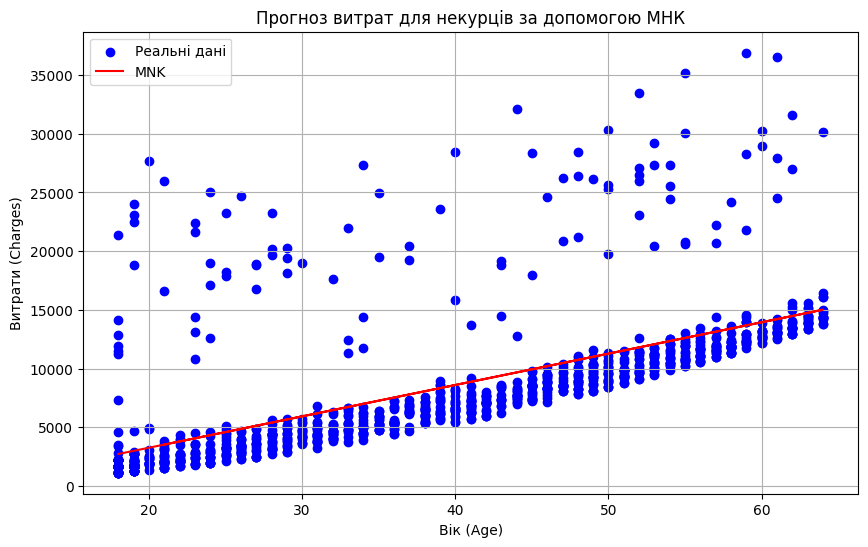

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='blue', label='Реальні дані')
plt.plot(x_data, predictions_MNK, color='red', label='MNK')
plt.xlabel('Вік (Age)')
plt.ylabel('Витрати (Charges)')
plt.title('Прогноз витрат для некурців за допомогою МНК')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
#Full-Batch градієнтного спуску
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [26]:
X_gradient = x_data.reshape(len(x_data), 1)
m, b, errors = full_batch_gradient_descent(X_gradient, y_data, lr=0.001, epochs=20000)
predictions_fbgd = m * X_gradient[:, 0] + b
m, b

/tmp/ipykernel_10430/1840707726.py:9: RuntimeWarning: overflow encountered in scalar add
  errors.append(sum(error**2))
/tmp/ipykernel_10430/1840707726.py:9: RuntimeWarning: overflow encountered in square
  errors.append(sum(error**2))
/tmp/ipykernel_10430/1840707726.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


(np.float64(nan), np.float64(nan))

In [30]:
m, b, errors = full_batch_gradient_descent(X_gradient, y_data, lr=0.0001, epochs=20000)
predictions_fbgd = m * X_gradient[:, 0] + b
m, b

(np.float64(237.23837970098563), np.float64(-758.5424388094132))

In [28]:
m, b, errors = full_batch_gradient_descent(X_gradient, y_data, lr=0.00001, epochs=20000)
predictions_fbgd = m * X_gradient[:, 0] + b
m, b

(np.float64(222.13768964996666), np.float64(-87.86527207324227))

In [32]:
print("Початкові помилки:", errors[:5])
print("Фінальні помилки:", errors[-5:])

Початкові помилки: [np.float64(113878364137.68318), np.float64(61771382439.92946), np.float64(39759524299.74568), np.float64(30460917858.439075), np.float64(26532841578.297344)]
Фінальні помилки: [np.float64(23344418577.534054), np.float64(23344408878.87774), np.float64(23344399180.660618), np.float64(23344389482.88271), np.float64(23344379785.543972)]


learning rate 0.0001 найкращий серед протестованих: якщо порівнювати початкову помилку і фінальну - то помилка стає меньшою і кроки теж стають меньшими.


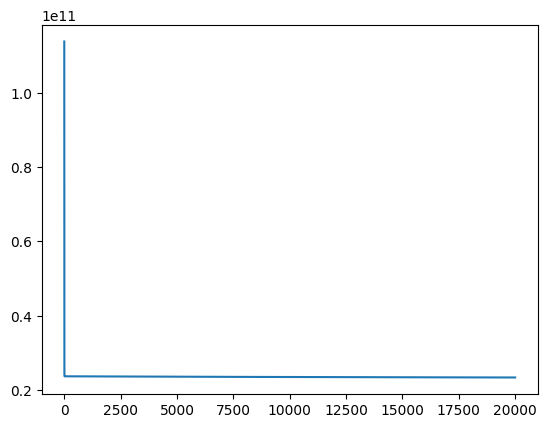

In [31]:
plt.plot(errors);

In [36]:
#З scikit-learn.LinearRegression
from sklearn.linear_model import LinearRegression

X_sl = non_smoker_df['age'].to_frame().values
lin_reg = LinearRegression()
lin_reg.fit(X_sl, y_data)

In [39]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [40]:
predictions_sklearn = lin_reg.predict(X_sl)

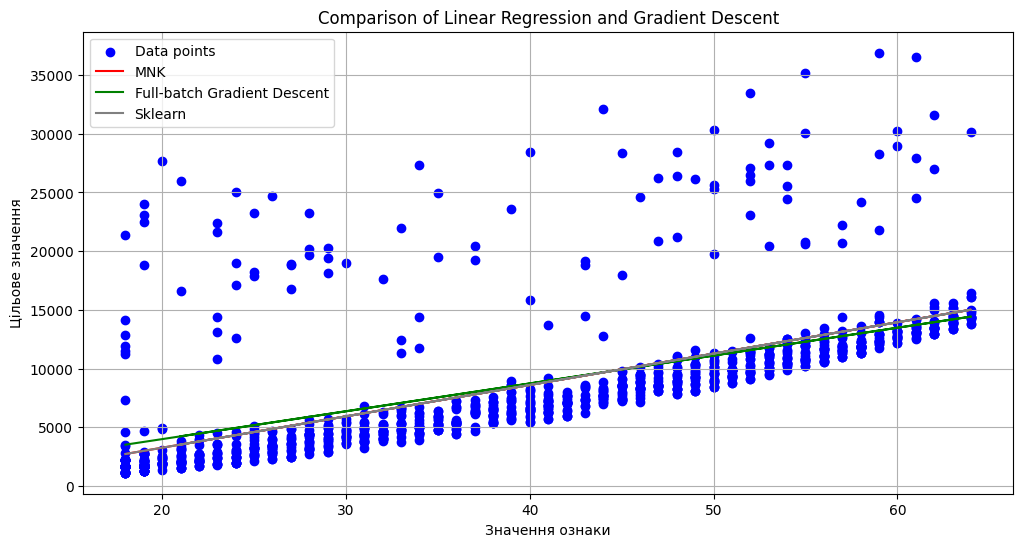

In [41]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(x_data, y_data, color='blue', label='Data points')
plt.plot(X[:, 1], predictions_MNK, color='red', label='MNK')
plt.plot(x_data, predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(x_data, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
from sklearn.metrics import mean_squared_error
rmse_MNK = np.sqrt(mean_squared_error(y_data, predictions_MNK))
print('RMSE МНК: ', rmse_MNK)
rmse_fbgd = np.sqrt(mean_squared_error(y_data, predictions_fbgd.flatten()))
print('RMSE град. спуску: ', rmse_fbgd)
rmse_sklearn = np.sqrt(mean_squared_error(y_data, predictions_sklearn))
print('RMSE sklearn: ', rmse_sklearn)

RMSE МНК:  4662.505766636395
RMSE град. спуску:  4684.036448591474
RMSE sklearn:  4662.505766636395


RMSE МНК та RMSE sklearn однакові (4662.51) а RMSE град. спуску трохи більша мабудь тому, що було замало єпох прі learning rate = 0.0001.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [49]:
smoker_df = medical_df[medical_df.smoker == 'yes']
x_smoker = smoker_df['age'].to_frame().values
y_smoker = smoker_df['charges'].values

In [50]:
lin_reg = LinearRegression()
lin_reg.fit(x_smoker, y_smoker)

LinearRegression()

In [51]:
lin_reg.coef_, lin_reg.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [52]:
predictions_sklearn_smoker = lin_reg.predict(x_smoker)
rmse_sklearn_smoker = np.sqrt(mean_squared_error(y_smoker, predictions_sklearn_smoker))
print('RMSE sklearn: ', rmse_sklearn_smoker)

RMSE sklearn:  10711.00334810241


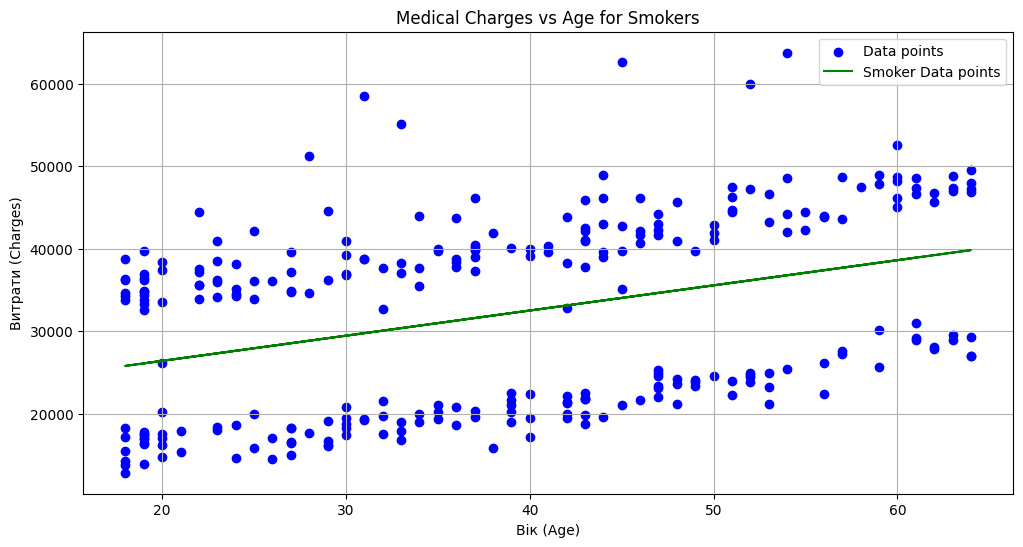

In [56]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(x_smoker, y_smoker, color='blue', label='Data points')
plt.plot(x_smoker, predictions_sklearn_smoker, color='green', label='Smoker Data points')
plt.title('Medical Charges vs Age for Smokers')
plt.xlabel('Вік (Age)')
plt.ylabel('Витрати (Charges)')
plt.legend()
plt.grid(True)
plt.show()

Помилка RSME досить велика - 10711, що говорить про низьку точність прогнозу.
На графіку видно що дані курців розділені на дві окремі групи і лінія регресії не може дати чіткого прогнозу.